(1508, 14)
(1508, 15)
(1507, 14)


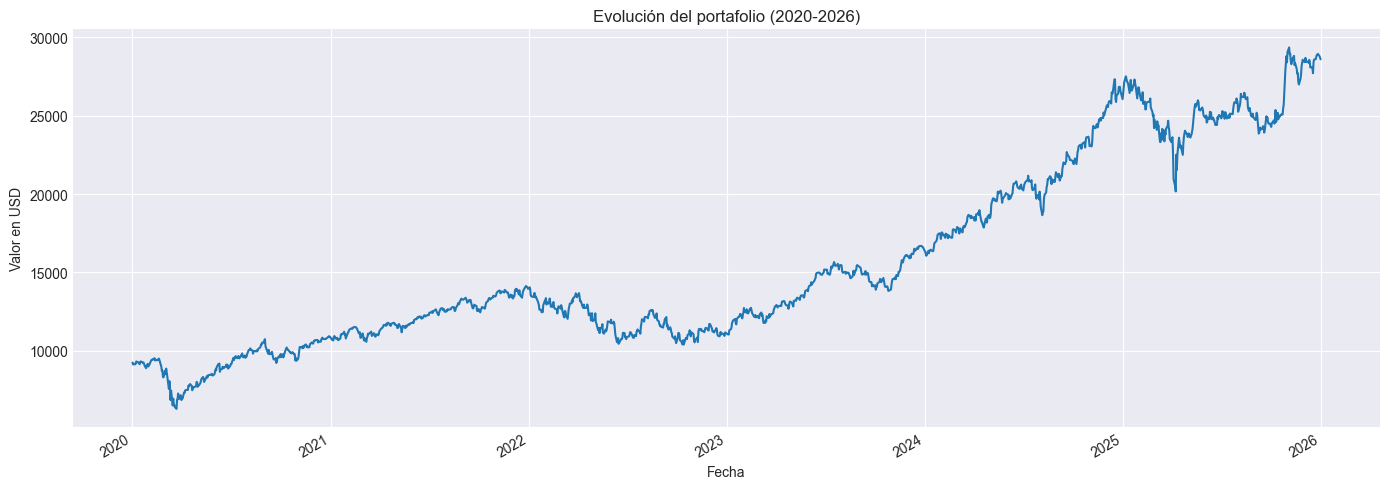

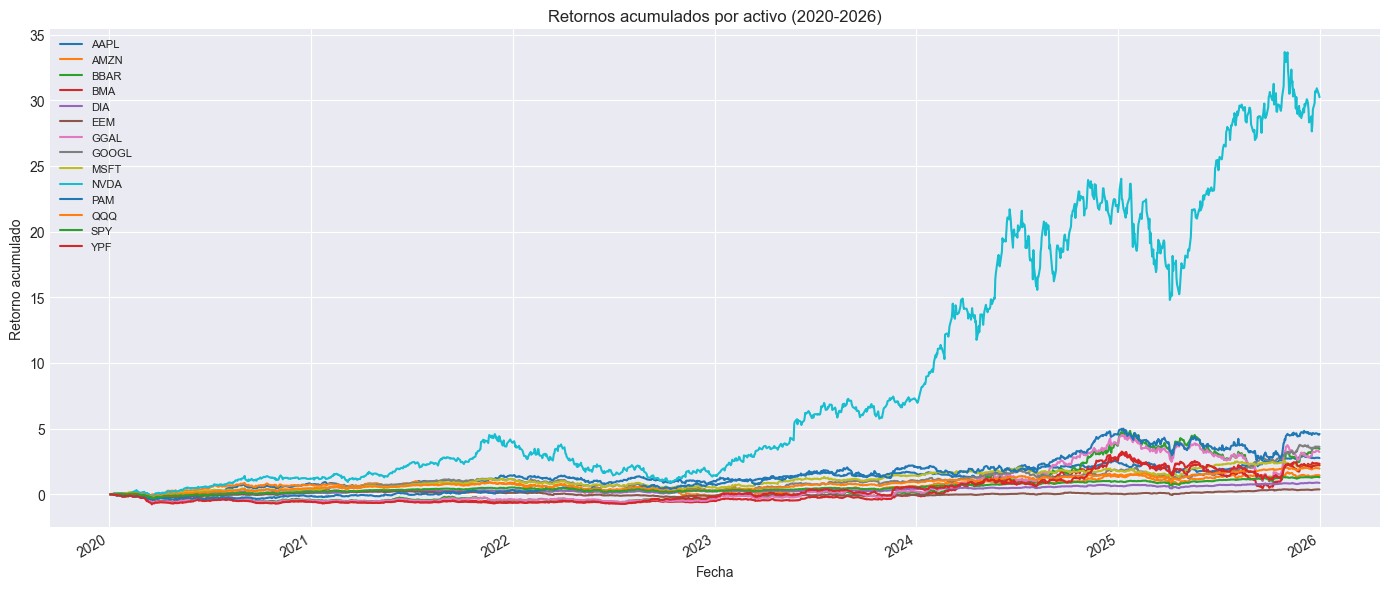

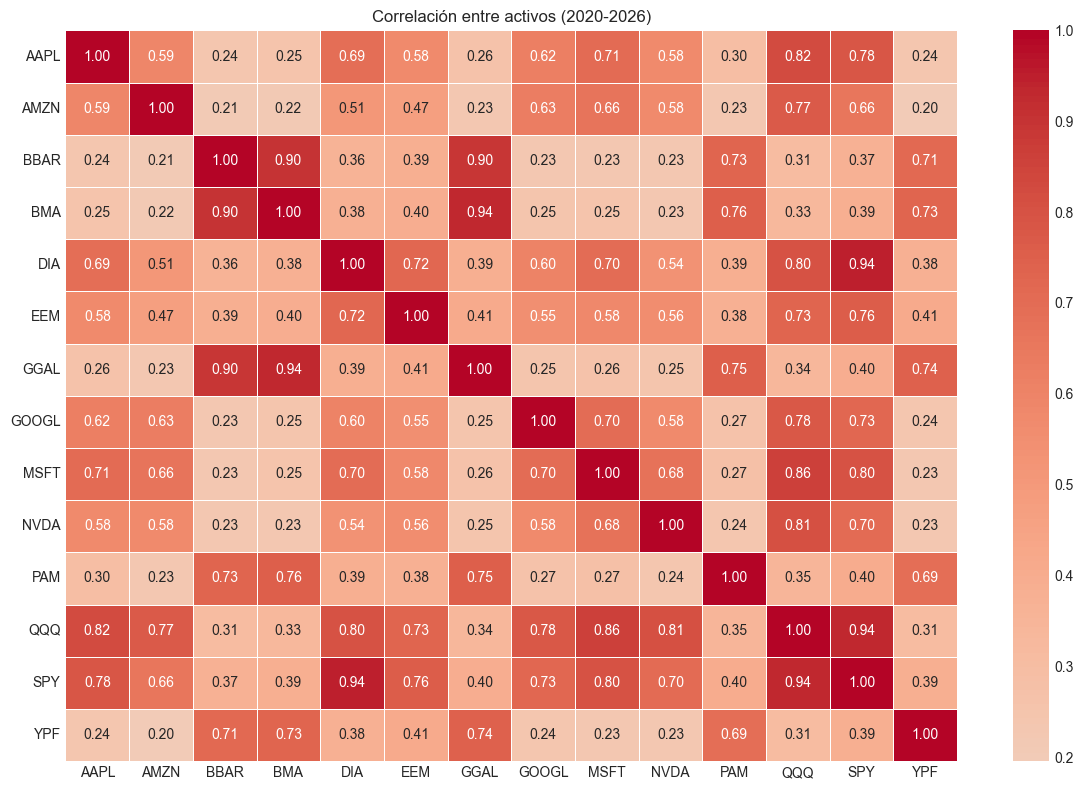

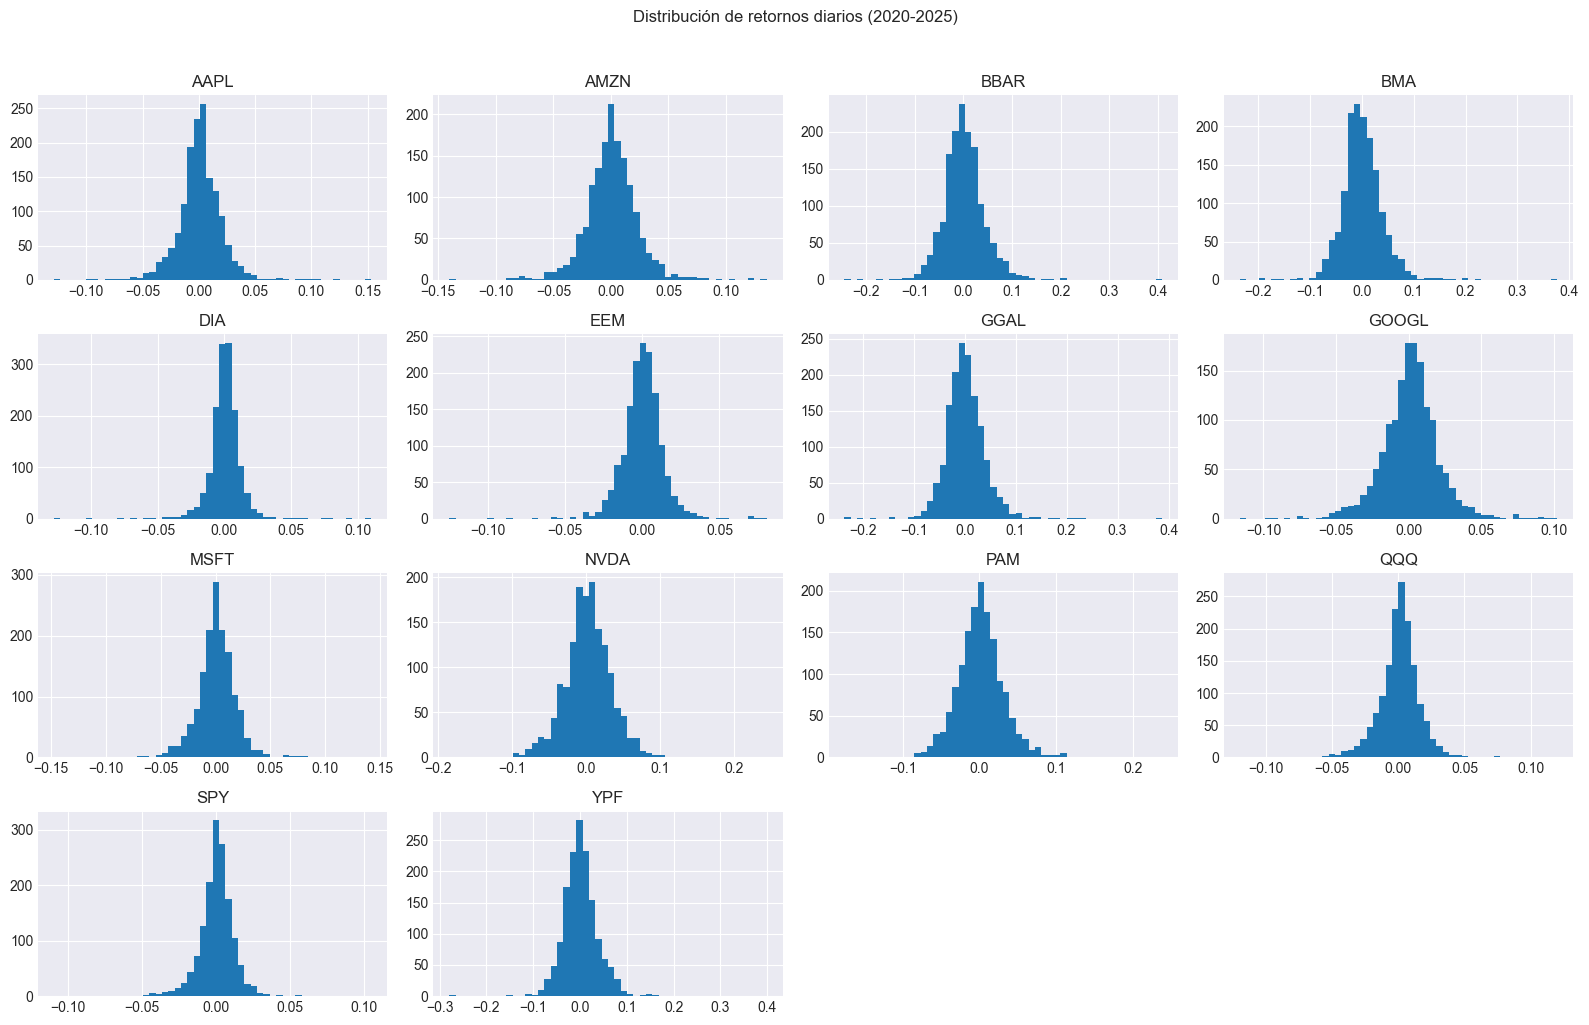

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path("../data")

plt.style.use("seaborn-v0_8-darkgrid")

precios = pd.read_csv(DATA / "precios_limpios.csv", index_col=0, parse_dates=True, date_format="ISO8601")
valor_portafolio = pd.read_csv(DATA / "valor_portafolio.csv", index_col=0, parse_dates=True, date_format="ISO8601")
retornos = precios.pct_change().dropna()

print(precios.shape)
print(valor_portafolio.shape)
print(retornos.shape)

valor_portafolio["Total_portafolio"].plot(figsize=(14, 5))

plt.title("Evolución del portafolio (2020-2026)")
plt.xlabel("Fecha")
plt.ylabel("Valor en USD")
plt.tight_layout()
plt.show()

retornos_acumulados = (1 + retornos).cumprod() - 1

retornos_acumulados.plot(figsize=(14, 6))

plt.title("Retornos acumulados por activo (2020-2026)")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))

sns.heatmap(
    retornos.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre activos (2020-2026)")
plt.tight_layout()
plt.show()

retornos.hist(figsize=(16, 10), bins=50, edgecolor="none")

plt.suptitle("Distribución de retornos diarios (2020-2025)", y=1.02)
plt.tight_layout()
plt.show()
